# QBUS3340 Group Assignment
## Task 1 Preform lot-sizing MILP (capacitated, with backorders)

In [ ]:
'''
Usage:
    pip install pulp pandas openpyxl
    python task1_lot_sizing.py <demand_workbook.xlsx> [sheet_name]
'''
# import sys # This is only need if using a py file
import pandas as pd
import pulp

# ---------------- Parameters ----------------
K = 1000   # fixed setup cost per batch ($)
h = 15     # holding cost per preform per day ($)
c = 10     # variable production cost per preform ($)
b = 100    # backorder cost per preform per day ($)
M = 100    # maximum batch size (units)
I0 = 20    # initial finished-preform inventory (day 0)
B0 = 0     # initial backorders
T = list(range(1, 21))

In [2]:
def load_demand(path, sheet=None):
    df = pd.read_excel(path, sheet_name=sheet if sheet else "Confirmed_20_Day_Demand")
    col = next(c_ for c_ in df.columns if "demand" in str(c_).lower())
    d = df[col].dropna().astype(float).tolist()[:20]
    if len(d) != 20:
        raise ValueError(f"Expected 20 demand values, found {len(d)}")
    return {t: d[t - 1] for t in T}


In [3]:
def solve(d):
    m = pulp.LpProblem("Task1_Preform_LotSizing", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("x", T, lowBound=0, cat="Integer")   # production
    y = pulp.LpVariable.dicts("y", T, cat="Binary")                # setup
    I = pulp.LpVariable.dicts("I", [0] + T, lowBound=0)            # end-of-day inventory
    B = pulp.LpVariable.dicts("B", [0] + T, lowBound=0)            # end-of-day backorders

    setup = pulp.lpSum(K * y[t] for t in T)
    var = pulp.lpSum(c * x[t] for t in T)
    hold = pulp.lpSum(h * I[t] for t in T)
    back = pulp.lpSum(b * B[t] for t in T)
    m += setup + var + hold + back

    m += I[0] == I0
    m += B[0] == B0
    for t in T:
        m += I[t - 1] - B[t - 1] + x[t] - d[t] == I[t] - B[t], f"balance_{t}"
        m += x[t] <= M * y[t], f"capacity_{t}"
    m += B[20] == 0, "all_orders_met"

    m.solve(pulp.PULP_CBC_CMD(msg=False))
    status = pulp.LpStatus[m.status]

    plan = pd.DataFrame({
        "day": T,
        "demand": [d[t] for t in T],
        "setup": [int(round(y[t].value())) for t in T],
        "production": [int(round(x[t].value())) for t in T],
        "end_inventory": [round(I[t].value(), 2) for t in T],
        "end_backorder": [round(B[t].value(), 2) for t in T],
    })
    costs = {
        "setup": setup.value(), "variable": var.value(),
        "holding": hold.value(), "backorder": back.value(),
    }
    costs["total"] = sum(costs.values())
    return status, plan, costs



In [9]:

path = "ZORA_synthetic_demand_data.xlsx"
sheet = None

demand = load_demand(path, sheet)
status, plan, costs = solve(demand)

print("Status:", status)
print(plan.to_string(index=False))

Status: Optimal
 day  demand  setup  production  end_inventory  end_backorder
   1    56.0      1          91           55.0            0.0
   2    55.0      0           0            0.0            0.0
   3    54.0      1          93           39.0            0.0
   4    39.0      0           0            0.0            0.0
   5    56.0      1          56            0.0            0.0
   6    58.0      1          58            0.0            0.0
   7    61.0      1          61            0.0            0.0
   8    72.0      1          72            0.0            0.0
   9    64.0      1          64            0.0            0.0
  10    62.0      1          62            0.0            0.0
  11    71.0      1          71            0.0            0.0
  12    57.0      1          68           11.0            0.0
  13    56.0      1         100           55.0            0.0
  14    55.0      0           0            0.0            0.0
  15    69.0      1          69            0.0        

In [10]:
print("\nCost breakdown ($):")
for k_, v in costs.items():
    print(f"  {k_:<10}{v:>12,.2f}")
print("\nSetup days:", plan.loc[plan.setup == 1, "day"].tolist())
# plan.to_csv("task1_plan.csv", index=False)


Cost breakdown ($):
  setup        16,000.00
  variable     11,370.00
  holding       3,150.00
  backorder         0.00
  total        30,520.00

Setup days: [1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 20]


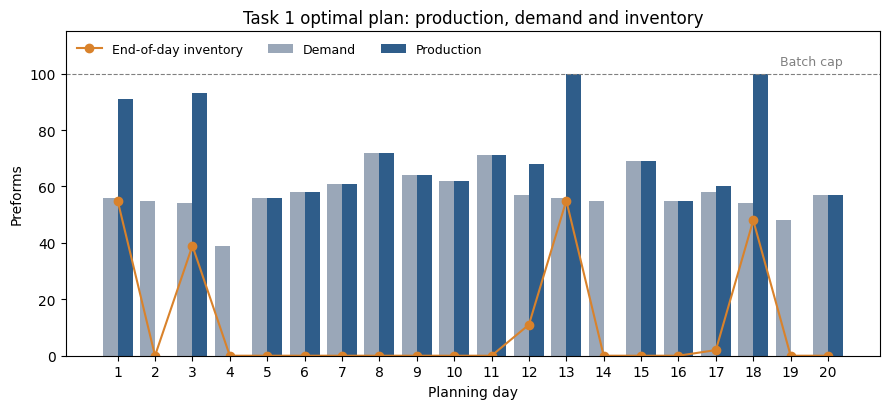

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.2))
w = 0.4
ax.bar(plan.day - w / 2, plan.demand, w, label="Demand", color="#9aa7b8")
ax.bar(plan.day + w / 2, plan.production, w, label="Production", color="#2f5d8a")
ax.plot(plan.day, plan.end_inventory, "o-", color="#d9822b", label="End-of-day inventory")
ax.axhline(M, ls="--", lw=0.8, color="grey")
ax.text(20.4, M + 2, "Batch cap", ha="right", va="bottom", fontsize=9, color="grey")
ax.set_xticks(T)
ax.set_xlabel("Planning day")
ax.set_ylabel("Preforms")
ax.set_title("Task 1 optimal plan: production, demand and inventory")
ax.legend(frameon=False, ncol=3, loc="upper left", fontsize=9)
ax.set_ylim(0, 115)
fig.tight_layout()
fig.savefig("task1_plan.png", dpi=200)